**Computational Methods — Class 1**
## Getting started with pandas

In this class, we use a voter-level dataset to learn the basics of **Python and pandas**.

We will learn how to:

- load a dataset;
- inspect rows, columns, and data types;
- select variables and observations;
- calculate simple descriptive statistics;
- compare groups;
- create a new variable;
- make a simple plot.

**Before you start**

*   Save your own copy first. **Go to File → Save a copy in Drive**. A new tab opens with your own copy. Work in that tab; edits to the original are not saved.

*   The data loads itself. There is nothing to download or upload. The setup cell below pulls the data straight from the course repository; you just need to be online.

## 1. Import pandas

`pandas` is one of the main Python libraries for working with tabular data.

The central object in pandas is a **DataFrame**, which looks a lot like a spreadsheet.


In [1]:
import numpy as np
import pandas as pd
import requests
from io import StringIO
import seaborn as sb
import matplotlib.pyplot as plt
sb.set_context('paper')
sb.set_style('dark')
%matplotlib inline

## 2. Load the voter dataset

The dataset shown in the class materials contains **60,000 voters** and 12 variables.

If you are using Google Colab, run the cell below and upload the CSV file.

The code then stores the data in a DataFrame called `voters`.


In [2]:
# URL of the CSV file
url = ('http://giulianoformisano.github.io/datasets/district_voter_file.csv')

# Request the content of the URL
response = requests.get(url)

# Check if the request was successful
if response.status_code == 200:
    # Use StringIO to read the CSV text into a pandas DataFrame
    csv_data = StringIO(response.text)
    voters = pd.read_csv(csv_data)
    print(voters.head())
else:
    print('Failed to retrieve the file. Status code:', response.status_code)


   voter_id  age  female party  voted_2012  voted_2014  voted_2016  \
0    913624   34       1     D           1           0           0   
1    926935   61       0     D           1           1           1   
2    957515   29       0     R           0           0           0   
3    919866   23       0     U           0           0           0   
4    939038   47       1     D           1           0           0   

   voted_2018  voted_2020  voted_2022  voted_2024  keystone_score  
0           0           1           0           1          0.6152  
1           1           1           1           1          0.9973  
2           0           1           1           1          0.5136  
3           0           0           0           1          0.5290  
4           0           1           0           0          0.5818  


### First look at the data

`.head()` shows the first few rows of a DataFrame.


In [ ]:
voters.head()


,voter_id,age,female,party,voted_2012,voted_2014,voted_2016,voted_2018,voted_2020,voted_2022,voted_2024,keystone_score
0,913624,34,1,D,1,0,0,0,1,0,1,0.6152
1,926935,61,0,D,1,1,1,1,1,1,1,0.9973
2,957515,29,0,R,0,0,0,0,1,1,1,0.5136
3,919866,23,0,U,0,0,0,0,0,0,1,0.5290
4,939038,47,1,D,1,0,0,0,1,0,0,0.5818


### How large is the dataset?

`.shape` returns the number of **rows** and **columns**.


In [ ]:
voters.shape


(60000, 12)

### What are the variables?

`.columns` gives us the names of all columns.


In [ ]:
voters.columns.to_list()


['voter_id',
 'age',
 'female',
 'party',
 'voted_2012',
 'voted_2014',
 'voted_2016',
 'voted_2018',
 'voted_2020',
 'voted_2022',
 'voted_2024',
 'keystone_score']

### What type of data are we working with?

`.dtypes` shows the data type of each variable.


In [ ]:
voters.dtypes


,0
voter_id,int64
age,int64
female,int64
party,object
voted_2012,int64
voted_2014,int64
voted_2016,int64
voted_2018,int64
voted_2020,int64
voted_2022,int64


## 3. Looking at variables

We can select a single column by putting its name in square brackets.

For example, let's look at `age`.


In [ ]:
voters["age"].head()


,age
0,34
1,61
2,29
3,23
4,47


We can also select several columns at once by providing a list of column names.


In [ ]:
voters[["age", "party", "voted_2024"]].head()


,age,party,voted_2024
0,34,D,1
1,61,D,1
2,29,R,1
3,23,U,1
4,47,D,0


## 4. Descriptive statistics

For a numeric variable, `.describe()` gives us useful descriptive statistics such as the mean, standard deviation, minimum, and maximum.


In [ ]:
voters["age"].describe()


,age
count,60000.000000
mean,49.850717
std,17.822720
min,20.000000
25%,35.000000
50%,50.000000
75%,63.000000
max,90.000000


We can also calculate individual statistics.

For example, the average age:


In [ ]:
voters["age"].mean()


np.float64(49.85071666666666)

And the median age:


In [ ]:
voters["age"].median()


50.0

## 5. Looking at categorical variables

`party` contains the party category for each voter.

`.value_counts()` tells us how many observations fall into each category.


In [ ]:
voters["party"].value_counts()


,count
party,
D,21625
R,19877
U,18498


We can ask for proportions rather than counts by using `normalize=True`.


In [ ]:
voters["party"].value_counts(normalize=True)


,proportion
party,
D,0.360417
R,0.331283
U,0.308300


## 6. Selecting observations with conditions

A common task in political science is to focus on a particular group.

For example, we can select voters aged 65 or older:


In [ ]:
older_voters = voters[voters["age"] >= 65]

older_voters.head()


,voter_id,age,female,party,voted_2012,voted_2014,voted_2016,voted_2018,voted_2020,voted_2022,voted_2024,keystone_score
12,901551,86,0,D,1,1,1,1,1,1,1,0.9331
17,957969,70,1,D,1,1,1,1,1,0,1,0.9742
26,941445,70,1,D,1,1,1,1,1,1,1,0.9742
37,921924,67,0,R,0,0,0,0,0,0,0,0.4160
43,904029,83,1,R,1,1,1,1,1,1,1,0.9408


We can check how many observations are in this new DataFrame.


In [ ]:
older_voters.shape


(13497, 12)

We can also combine conditions.

For example, voters aged 65 or older who are coded as female (`female == 1`):


In [ ]:
older_female_voters = voters[
    (voters["age"] >= 65) &
    (voters["female"] == 1)
]

older_female_voters.head()


,voter_id,age,female,party,voted_2012,voted_2014,voted_2016,voted_2018,voted_2020,voted_2022,voted_2024,keystone_score
17,957969,70,1,D,1,1,1,1,1,0,1,0.9742
26,941445,70,1,D,1,1,1,1,1,1,1,0.9742
43,904029,83,1,R,1,1,1,1,1,1,1,0.9408
47,950857,80,1,U,1,1,1,1,1,1,1,0.9485
56,939601,88,1,U,1,1,1,1,1,1,1,0.9280


## 7. Comparing groups

`groupby()` is especially useful in political science because we often want to compare a variable across groups.

For example, what is the average age by party?


In [ ]:
voters.groupby("party")["age"].mean()


,age
party,
D,51.642913
R,51.298083
U,46.200292


### Turnout

The variables `voted_2012`, `voted_2014`, ..., `voted_2024` are coded as 0/1 in the dataset.

For a binary variable, its mean is the proportion coded `1`.

Let's calculate the proportion voting in 2024 by party:


In [ ]:
voters.groupby("party")["voted_2024"].mean()


,voted_2024
party,
D,0.773272
R,0.780399
U,0.721808


We can do the same for several election years at once.


In [ ]:
voters.groupby("party")[
    ["voted_2012", "voted_2016", "voted_2020", "voted_2024"]
].mean()


,voted_2012,voted_2016,voted_2020,voted_2024
party,,,,
D,0.603977,0.656139,0.735306,0.773272
R,0.601600,0.653821,0.738743,0.780399
U,0.508487,0.566223,0.664937,0.721808


## 8. Creating a new variable

We can create a new column using existing columns.

Here, we create an `age_group` variable with three broad age categories.


In [ ]:
voters["age_group"] = pd.cut(
    voters["age"],
    bins=[0, 29, 64, 120],
    labels=["18–29", "30–64", "65+"]
)

voters[["age", "age_group"]].head()


,age,age_group
0,34,30–64
1,61,30–64
2,29,18–29
3,23,18–29
4,47,30–64


Now we can compare 2024 turnout across these age groups.


In [ ]:
voters.groupby("age_group", observed=True)["voted_2024"].mean()


,voted_2024
age_group,
18–29,0.669505
30–64,0.754529
65+,0.838483


## 9. A simple visualization

A quick way to visualise a group comparison is with a bar chart.

The following plot shows the proportion voting in 2024 by party.


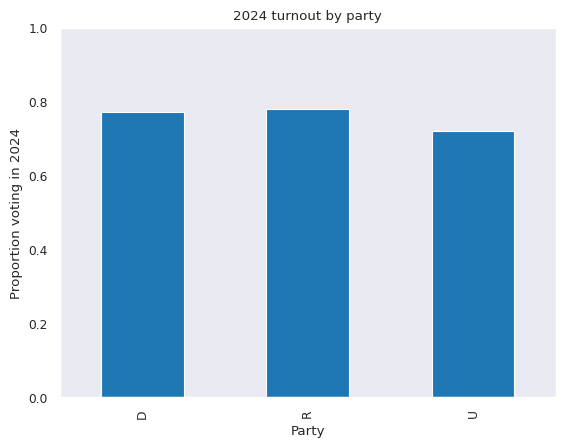

In [ ]:
turnout_by_party = voters.groupby("party")["voted_2024"].mean()

turnout_by_party.plot(kind="bar")
plt.ylabel("Proportion voting in 2024")
plt.xlabel("Party")
plt.title("2024 turnout by party")
plt.ylim(0, 1)
plt.show()


## 10. Checking the `keystone_score`

**Keystone score:** A turnout score purchased from Keystone Analytics for every registered voter. The score ranges from 0 to 1 and represents the vendor's predicted likelihood that a voter will turn out. Because we also observe actual turnout, we can use the voter file to evaluate the score.

We can use the same descriptive tools for `keystone_score`.

First, inspect its distribution:


In [ ]:
voters["keystone_score"].describe()


,keystone_score
count,60000.000000
mean,0.754469
std,0.204341
min,0.356900
25%,0.534100
50%,0.759800
75%,0.969100
max,1.000000


We can also compare the average score across party categories.

Remember that this is a **descriptive comparison**: it does not tell us why the groups differ.


In [ ]:
voters.groupby("party")["keystone_score"].mean()


,keystone_score
party,
D,0.768369
R,0.766443
U,0.725353


## 11. A useful habit: checking missing data

Before analysing a variable, it is useful to check whether values are missing.

`.isna().sum()` counts missing observations in each column.


In [ ]:
voters.isna().sum()


,0
voter_id,0
age,0
female,0
party,0
voted_2012,0
voted_2014,0
voted_2016,0
voted_2018,0
voted_2020,0
voted_2022,0


# In-class exercises

For each exercise, provide:

1. the Python code;
2. the output;
3. **2–3 sentences interpreting the result in political-science terms.**

Keep the interpretation descriptive. Do not make causal claims from these comparisons.

### Exercise 1 — Age and party

Calculate the **mean age** for each party category.

Which party categories have the highest and lowest average age in this dataset?

### Exercise 2 — Electoral participation

Calculate the **proportion voting in 2024** for each party category.

Describe the differences you observe.

### Exercise 3 — Age and turnout

Calculate the proportion voting in 2024 for each `age_group`.

What pattern do you observe across the three age groups?

### Exercise 4 — Exploring Keystone Analytics (EXTRA)

Use keystone_score to investigate how the vendor's score relates to actual turnout in 2024.

- Describe the distribution of keystone_score.
- Divide voters into five groups based on their Keystone score.
- Calculate the 2024 turnout rate for each group.
- Make a simple plot showing the relationship between Keystone's score and actual turnout.
- In 2–3 sentences, assess whether the score appears to distinguish between voters who did and did not turn out.

**Bonus:** Which group has the largest gap between the predicted turnout score and the actual 2024 turnout rate?



## Optional challenge

Create a new variable called `voted_all_elections` that equals 1 when a voter is coded as having voted in **all seven election years** in the dataset, and 0 otherwise.

Then calculate the proportion of voters who satisfy this condition.

**Hint:** you can add the seven voting variables together and check whether the sum equals 7.


In [ ]:
vote_columns = [
    "voted_2012", "voted_2014", "voted_2016",
    "voted_2018", "voted_2020", "voted_2022", "voted_2024"
]

voters["voted_all_elections"] = (
    voters[vote_columns].sum(axis=1) == 7
).astype(int)

voters["voted_all_elections"].mean()


np.float64(0.28073333333333333)